# Heatbudget AREA1 
## Module 导入 与 常量生成

In [1]:
import os
import datetime
import numpy as np
import scipy as sp
import pandas as pd
import netCDF4 as nc
import PIL.Image as Image
import cartopy.crs as ccrs
import marineHeatWaves as mhw
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from datetime import date
from tqdm import notebook
from scipy.stats import pearsonr
from matplotlib.backends.backend_agg import FigureCanvasAgg
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor


## 导入气候态数据

In [2]:
def chaaxis(dat):
    a=np.swapaxes(dat,1,2)
    a=np.swapaxes(a,0,1)
    return a
climdata=np.load("/lustre/home/yuhanxue/data/heatbudgetV2/area1_07~09_mltt_Q_HADV_clim.npz")
mltt_area1_a_clim=chaaxis(climdata['mltt_area1_a_clim'])
Q_area1_a1_clim=chaaxis(climdata['Q_area1_a1_clim'])
HADV_area1_a1_clim=chaaxis(climdata['HADV_area1_a_clim'])
ovmix_area1_a1_clim=chaaxis(climdata['ovmix_area1_a_clim'])
# climdata.files

## 常量生成

In [3]:
time=pd.date_range('2021-7-1','2021-9-30')

## $Q$ 表面净热通量总和

### Functions

$$
Q=\frac{Q_{net}-Q_{z}}{\rho_{0}C_{p}h}
$$
- $Q_{net}=Q_{ShortwaveRadiation}+Q_{LongwaveRadiation}+Q_{LatentHeatFlux}+Q_{SensibleHeatFlux}$
- $Q_{z}=Q_{ShortwaveRadiation}(0.58e^{\frac{h}{0.35}}+0.42e^\frac{h}{23})$
- $\rho _{0}: 1.024 g/cm^{3}$
- $C_{p}: 3850 J\cdot kg^{-1} \cdot C^{-1}$
- *h*为*MLD*，*混合层深度* 与**海表温差2℃**

### Data list

- *h*(MLD)
  - [depth](/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy)
  - [thetao2021](/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy)
- $Q_{ShortwaveRadiation}$ 
  - [ssrs](/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy)
- $Q_{LongwaveRadiation}$ 
  - [strs](/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy)
- $Q_{LatentHeatFlux}$ 
  - [slhf](/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy)
- $Q_{SensibleHeatFlux}$ 
  - [sshf](lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy)

### 计算MLD


In [4]:
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def mld(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return depth[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map(dat):
    ans=np.array(list(map(mld,dat)))
    return ans
def onetime(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map,a)))
    return ans
thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=72)
mld2021a1=np.array(list(pool.map(onetime,thetaos2020a1)))
del pool

### 读取$Q_{ShortwaveRadiation}$、$Q_{LongwaveRadiation}$、$Q_{LatentHeatFlux}$、$Q_{SensibleHeatFlux}$ 

In [5]:
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/time.npy",allow_pickle=True))
time2021ind=(times.year==2021)&((times.month==7)|(times.month==8)|(times.month==9))
msnlwrfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msnlwrfs.npy')[time2021ind]#ShortwaveRadiation
msnswrfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msnswrfs.npy')[time2021ind]#LongwaveRadiation
slhfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_mslhfs.npy')[time2021ind]#LatentHeatFlux
sshfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msshfs.npy')[time2021ind]#SensibleHeatFlux
del times,time2021ind

### 计算公式
- $Q_{net}=Q_{ShortwaveRadiation}+Q_{LongwaveRadiation}+Q_{LatentHeatFlux}+Q_{SensibleHeatFlux}$
- $Q_{z}=Q_{ShortwaveRadiation}(0.58e^{-\frac{h}{0.35}}+0.42e^{-\frac{h}{23}})$
- $Q=\frac{Q_{net}-Q_{z}}{\rho_{0}C_{p}h}$

In [6]:
Q_net=msnswrfs_2021+msnlwrfs_2021+slhfs_2021+sshfs_2021
Q_z=msnswrfs_2021*(0.58*np.exp(-1*mld2021a1/0.35)+0.42*np.exp(-1*mld2021a1/23))
Q=(Q_net-Q_z)/(1.024*1e3*3850*mld2021a1)*24*3600

Text(0.5, 1.0, 'Q')

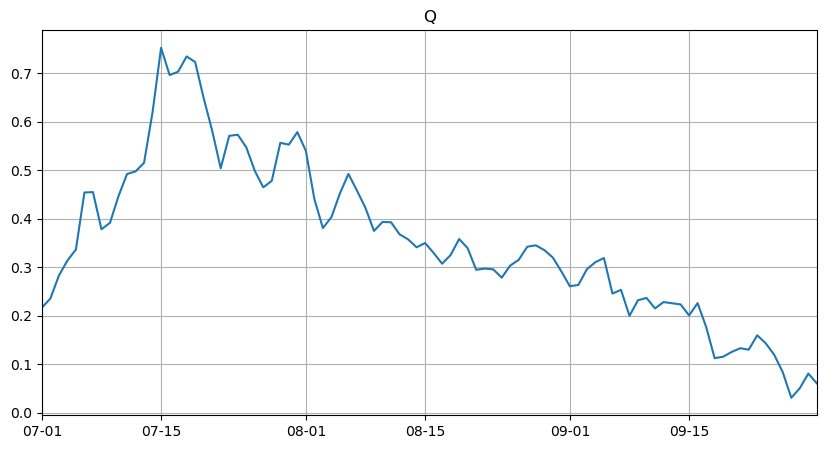

In [7]:
from matplotlib.dates import DateFormatter, MONDAY, MonthLocator, YearLocator
formatter = DateFormatter('%m-%d')
plt.figure(figsize=[10,5])
#time2021ind=(time_a.year==2019)&((time_a.month==7)|(time_a.month==8)|(time_a.month==9))
plt.plot(time,np.nanmean(np.nanmean(Q,axis=-1),axis=-1))
#plt.plot(time,[0]*time.shape[0],'r')
plt.xlim(time[0],time[-1])
ax=plt.gca()
ax.xaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Q')

In [8]:
1+1

2

## Mixed Layer Temperature Tendency
### Functions
$$
Mixed Layer Temperature Tendency=\frac{\mathrm{d}\mathrm{T_{m}}}{\mathrm{d}\mathrm{t}}
$$
- $\mathrm{T_{m}}$为$\mathrm{T_{0}}$至$\mathrm{T_{-h}}$的平均值
### Data list

- *h*(MLD)

### 计算tm&mltt


In [9]:
# T_m
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return np.nanmean(dat[dat[0]-0.8-dat<0])
    else:
        return np.nan
def list_map2(dat):
    ans=np.array(list(map(tm,dat)))
    return ans
def onetime2(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map2,a)))
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=72)
tms=np.array(list(pool.map(onetime2,thetaos2020a1)))
del pool
mltt=tms[1:,:,:]-tms[:-1,:,:]
#np.save('12_10mltt.npy',mltt)

## HADV 水平平流项
### Functions
$$
HADV=-\overrightarrow{U_{m}}\bigtriangledown T_{m}=-(u_{m}\frac{\mathrm{d}T_{m}}{\mathrm{d}x}+v_{m}\frac{\mathrm{d}T_{m}}{\mathrm{d}y})
$$
- $ \overrightarrow{U_{m}} $为0~h平均水平速度
- $T_{m}$为0~-h深度的平均位温
- $u_{m}$为水平经向速度
- $v_{m}$为水平纬向速度
- 注：纬度长度不固定，需要进行修正，修正公式:$111(Δ lon)\cdot cos(lat)$
### Data list
- uos
- vos
- tm
- lon_4
- lat_4

### 数据导入

In [10]:
us2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/uos_2021.npy")*3600*24
vs2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/vo_2021.npy")*3600*24
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lats.npy')[-1::-1]
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lons.npy')
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=195)&(lon_4<=230)
lat_4=lat_4[lat_4_ind]
lon_4=lon_4[lon_4_ind]
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')

lat_4 range:35.00~50.00 | freq:0.25
lon_4 range:195.00~230.00 | freq:0.25


### 计算$u_{m}$、$v_{m}$、经向&纬向积分、HADV

In [11]:
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[1,0]-0.8>dat[1,-1]:
        return np.nanmean(dat[0,dat[1,0]-0.8-dat[1,:]<0])
    else:
        return np.nan
def list_map2(dat):
    ans=np.array(list(map(tm,dat)))
    return ans
def onetime2(dat):
    #a=np.swapaxes(dat,0,1)
    #a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map2,dat)))
    #ans=np.array(list(map(list_map2,dat)))
    return ans

def ms(dat):
    global thetaos2020a1
    pool = ProcessPoolExecutor(max_workers=72)
    a=np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.array([dat,thetaos2020a1]),0,1),2,3),1,2),3,4),2,3)
    ans=np.array(list(pool.map(onetime2,a)))
    del pool
    return ans
um=ms(us2020a1)
vm=ms(vs2020a1)

dx=np.array([(tms[:,i,1:]-tms[:,i,:-1])/(111e3/4*np.cos(lat_4[i]/180*np.pi)) for i in range(0,61)])
dx=np.swapaxes(dx,0,1)
dy=(tms[:,1:,:]-tms[:,:-1,:])/(111e3/4)

hadv=(um[:,:-1,:-1]*dx[:,:-1,:]+um[:,:-1,:-1]*dy[:,:,:-1])*-1

In [12]:
ovmix=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]

In [13]:
mltt_T=mltt-mltt_area1_a_clim[:-1,:,:]
Q_T=Q-Q_area1_a1_clim
hadv_T=hadv-HADV_area1_a1_clim
ovmix_T=ovmix-ovmix_area1_a1_clim[:-1,:,:]
np.save('1_10mltt_t.npy',mltt_T)

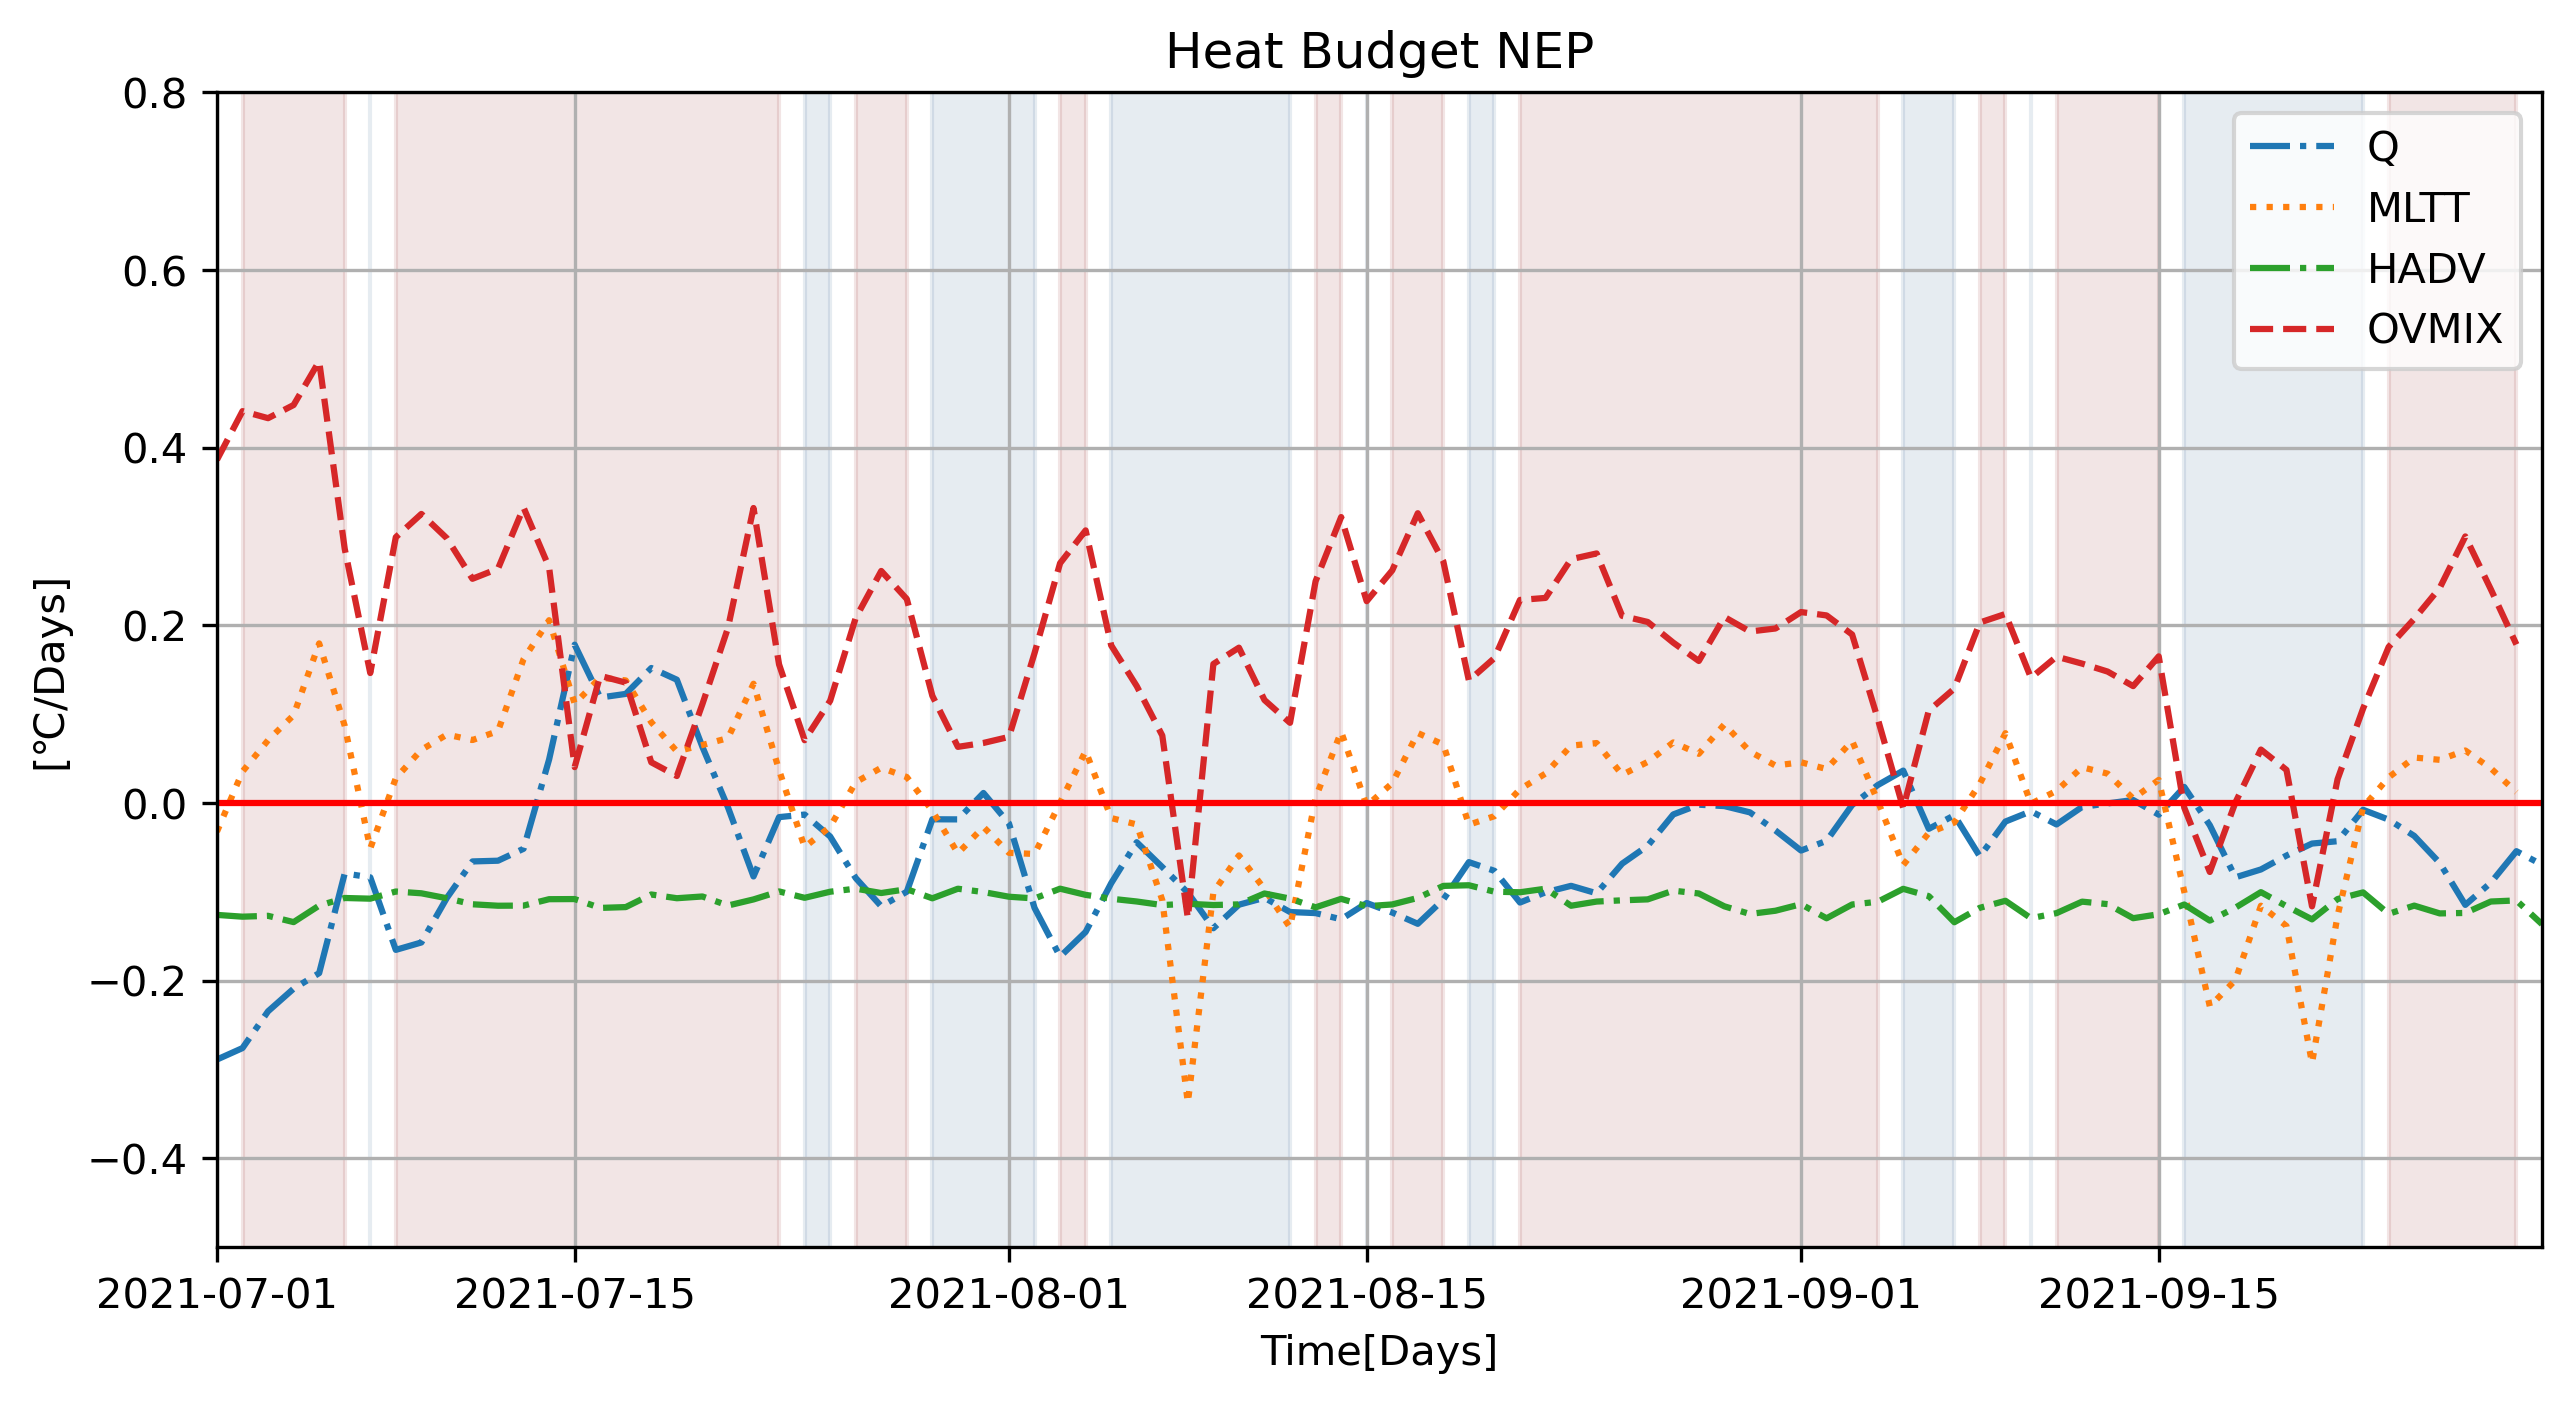

In [14]:
plt.figure(figsize=[10,5],dpi=300)
pc1 = pearsonr(np.mean(np.mean(Q_T,axis=1),axis=1)[:-1]+np.mean(np.mean(ovmix_T,axis=1),axis=1)+np.mean(np.mean(hadv_T,axis=1),axis=1)[:-1], np.mean(np.mean(mltt_T,axis=1),axis=1))
pc2 = pearsonr(np.mean(np.mean(ovmix_T,axis=1),axis=1), np.mean(np.mean(mltt_T,axis=1),axis=1)-np.mean(np.mean(Q_T,axis=1),axis=1)[:-1]-np.mean(np.mean(hadv_T,axis=1),axis=1)[:-1])
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1000
y0[:]=-1000
#plt.title('Heat Budget'+f'\nMLTT&(OVMIX+HADV+Q)->r={pc1[0]:.3f},S_Level={pc1[1]:.2e}'+f'\nOVMIX&RES->r={pc2[0]:.3f},S_Level={pc2[1]:.2e}')
plt.title('Heat Budget NEP')
plt.plot(time,np.mean(np.mean(Q_T,axis=1),axis=1),linestyle='-.',label='Q')
plt.plot(time[:-1],np.mean(np.mean(mltt_T,axis=1),axis=1),linestyle=':',label='MLTT')
plt.plot(time,np.mean(np.mean(hadv_T,axis=1),axis=1),linestyle='dashdot',label='HADV')
#pltsea of thieves Ocean.plot(time[:-1],np.mean(np.mean(ovmix1,axis=1),axis=1),label='ENT')
#plt.plot(time,np.mean(np.mean(ovmix2,axis=1),axis=1),label='MIX')
plt.plot(time[:-1],np.mean(np.mean(ovmix_T,axis=1),axis=1),linestyle='--',label='OVMIX')
plt.legend()
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-0.5,0.8)
plt.xlim(time[0],time[-1])
plt.ylabel('[℃/Days]')
plt.xlabel('Time[Days]')
plt.grid()

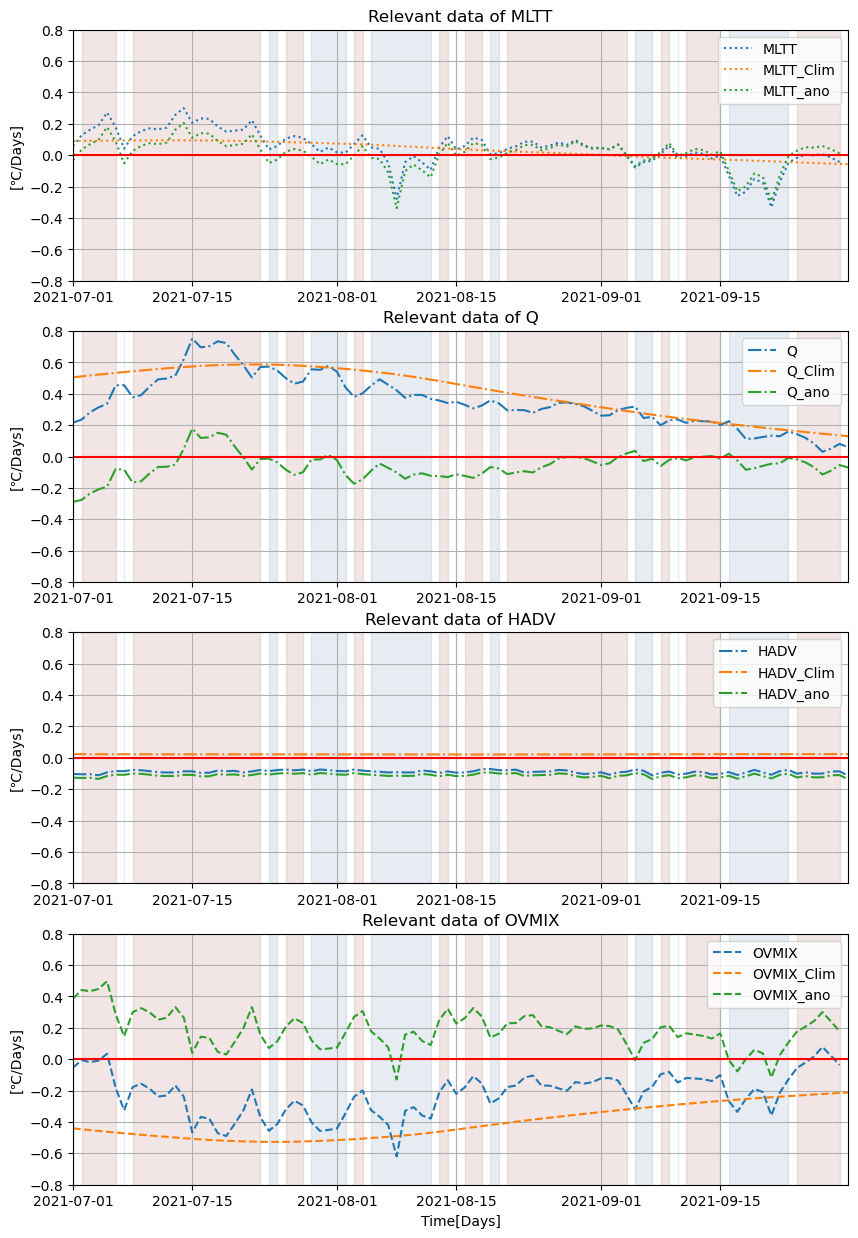

In [20]:
plt.figure(figsize=[10,15])
plt.subplot(4,1,1)
plt.title('Relevant data of MLTT')
plt.plot(time[:-1],np.mean(np.mean(mltt,axis=1),axis=1),linestyle=':',label='MLTT')
plt.plot(time,np.mean(np.mean(mltt_area1_a_clim,axis=1),axis=1),linestyle=':',label='MLTT_Clim')
plt.plot(time[:-1],np.mean(np.mean(mltt_T,axis=1),axis=1),linestyle=':',label='MLTT_ano')
plt.legend()
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.xlim(time[0],time[-1])
plt.ylim(-0.8,0.8)
plt.ylabel('[℃/Days]')
plt.grid()

plt.subplot(4,1,2)
plt.title('Relevant data of Q')
plt.plot(time,np.mean(np.mean(Q,axis=1),axis=1),linestyle='-.',label='Q')
plt.plot(time,np.mean(np.mean(Q_area1_a1_clim,axis=1),axis=1),linestyle='-.',label='Q_Clim')
plt.plot(time,np.mean(np.mean(Q_T,axis=1),axis=1),linestyle='-.',label='Q_ano')
plt.legend()
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.xlim(time[0],time[-1])
plt.ylim(-0.8,0.8)
plt.ylabel('[℃/Days]')
plt.grid()

plt.subplot(4,1,3)
plt.title('Relevant data of HADV')
plt.plot(time,np.mean(np.mean(hadv,axis=1),axis=1),linestyle='dashdot',label='HADV')
plt.plot(time,np.mean(np.mean(HADV_area1_a1_clim,axis=1),axis=1),linestyle='dashdot',label='HADV_Clim')
plt.plot(time,np.mean(np.mean(hadv_T,axis=1),axis=1),linestyle='dashdot',label='HADV_ano')
plt.legend()
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.xlim(time[0],time[-1])
plt.ylim(-0.8,0.8)
plt.ylabel('[℃/Days]')
plt.grid()

plt.subplot(4,1,4)
plt.title('Relevant data of OVMIX')
plt.plot(time[:-1],np.mean(np.mean(ovmix,axis=1),axis=1),linestyle='--',label='OVMIX')
plt.plot(time,np.mean(np.mean(ovmix_area1_a1_clim,axis=1),axis=1),linestyle='--',label='OVMIX_Clim')
plt.plot(time[:-1],np.mean(np.mean(ovmix_T,axis=1),axis=1),linestyle='--',label='OVMIX_ano')
plt.legend()
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.xlim(time[0],time[-1])
plt.ylim(-0.8,0.8)
plt.ylabel('[℃/Days]')
plt.xlabel('Time[Days]')
plt.grid()

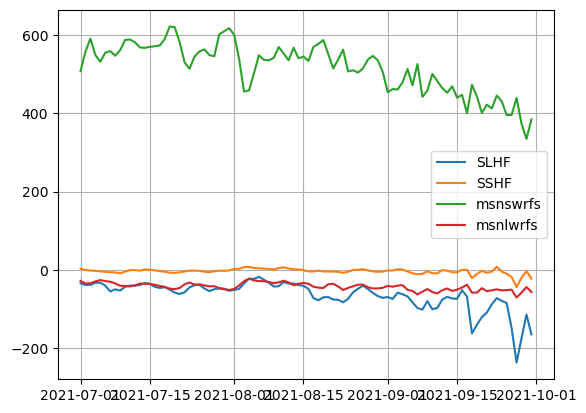

In [16]:
plt.plot(time,np.mean(np.mean(slhfs_2021,axis=1),axis=1),label='SLHF')
plt.plot(time,np.mean(np.mean(sshfs_2021,axis=1),axis=1),label='SSHF')
plt.plot(time,np.mean(np.mean(msnswrfs_2021,axis=1),axis=1),label='msnswrfs')
plt.plot(time,np.mean(np.mean(msnlwrfs_2021,axis=1),axis=1),label='msnlwrfs')
plt.legend()
plt.grid()